## **PyTorch task: Neural Network Classification**



In [5]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

FOLDERNAME = 'intro_to_ai/assignments/assignmnent1'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load

# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# This downloads the CIFAR-10 dataset to your Drive
# if it doesn't already exist.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Table of Contents (Adapted for Bonus Task)

This notebook has been adapted specifically for the regression bonus task. We will use PyTorch to build a deep neural network capable of predicting continuous values, rather than performing classification.

1. **Part I, Preparation:** We will load and preprocess the **Auto MPG** dataset (handling missing values, one-hot encoding, and scaling) and convert it to PyTorch Tensors.
2. **Part V, Bonus Task (Auto MPG Regression):** We will adapt the network architecture for regression (using a single output neuron and MSE loss) and evaluate its performance using RMSE.

# GPU

You can manually switch to a GPU device on Colab by clicking `Runtime -> Change runtime type` and selecting `GPU` under `Hardware Accelerator`. You should do this before running the following cells to import packages, since the kernel gets restarted upon switching runtimes.

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import sampler

import torchvision.datasets as dset
import torchvision.transforms as T

import numpy as np

USE_GPU = True
dtype = torch.float32 # We will be using float throughout this assignment.

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

# Constant to control how frequently we print train loss.
print_every = 100
print('using device:', device)

using device: cpu


### Part I. Preparation (Adapted for Bonus Task)

Now, let's load the **Auto MPG** dataset for our regression task.

Unlike the original notebook that loaded CIFAR-10 images using PyTorch's built-in utilities, here we fetch tabular vehicle data using the `ucimlrepo` library.

In this step, we will manually preprocess the dataset: we will handle missing values, perform one-hot encoding on categorical features, and standardize the numerical values. Finally, we will convert the processed data into PyTorch Tensors so our neural network can learn from it.

In [8]:
pip install ucimlrepo

In [16]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

# Ensure the device is defined (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Fetch data
auto_mpg = fetch_ucirepo(id=9)
X = auto_mpg.data.features
y = auto_mpg.data.targets

# 2. Preprocessing
full_df = pd.concat([X, y], axis=1)
full_df['horsepower'] = full_df['horsepower'].fillna(full_df['horsepower'].median())
X_proc = pd.get_dummies(full_df.drop('mpg', axis=1), columns=['origin'], drop_first=True)
y_proc = full_df['mpg']

# 3. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X_proc, y_proc, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Convert to Tensors (Ready for the neural network)
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1).to(device)

print("Auto MPG data is ready for Regression Task.")

Auto MPG data is ready for Regression Task.


## Part V. Bonus Task: Auto MPG Regression

In this section, we adapt our neural network architecture to perform **regression** instead of classification, satisfying the requirements of Section 5.1.

Our goal is to predict the continuous target variable `mpg` (Miles Per Gallon). To achieve this, we modified the deep model from Part IV in the following ways:
* **The model output layer:** Changed to a single neuron with no activation function.
* **The loss function:** Switched from Cross-Entropy to Mean Squared Error (MSE).
* **The evaluation procedure:** Replaced accuracy calculation with Root Mean Squared Error (RMSE) to properly evaluate regression performance.

Below is the code that defines the adapted architecture, trains the model, and plots the necessary evaluation figures (Training Loss and Predicted vs. Actual MPG).

## TO DO

### The model architecture,  Optimization choices, Regularization

Model Architecture

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Define the input dimension based on the processed Auto MPG dataset
input_dim = X_train_t.shape[1]

class MPGRegressor(nn.Module):
    def __init__(self, input_size):
        super(MPGRegressor, self).__init__()

        # Reduced dropout for a small dataset to prevent underfitting
        drop_rate = 0.05

        self.layers = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(drop_rate),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(drop_rate),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            # OUTPUT LAYER: 1 neuron, no activation function for regression
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.layers(x)

# Instantiate the model and move it to the correct device
model = MPGRegressor(input_dim).to(device)
print("Model architecture defined successfully.")

Model architecture defined successfully.


Loss Function & Optimizer

In [18]:
# The loss function: Mean Squared Error (MSE) for regression
criterion = nn.MSELoss()

# Optimizer with a slightly higher learning rate to avoid getting stuck
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

print("Loss function and optimizer defined.")

Loss function and optimizer defined.


Training Loop

In [25]:
epochs = 300
train_losses = []
val_losses = []

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    optimizer.zero_grad()
    predictions = model(X_train_t)
    loss = criterion(predictions, y_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # --- Validation Phase ---
    model.eval()
    with torch.no_grad():
        val_predictions = model(X_test_t)
        val_loss = criterion(val_predictions, y_test_t)
        val_losses.append(val_loss.item())

    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train MSE: {loss.item():.4f}, Val MSE: {val_loss.item():.4f}')

print("Training complete")

Epoch [50/300], Train MSE: 0.4970, Val MSE: 7.2435
Epoch [100/300], Train MSE: 0.4777, Val MSE: 7.2664
Epoch [150/300], Train MSE: 0.4053, Val MSE: 7.0714
Epoch [200/300], Train MSE: 0.4332, Val MSE: 7.2108
Epoch [250/300], Train MSE: 0.3901, Val MSE: 7.4714
Epoch [300/300], Train MSE: 0.3694, Val MSE: 6.9884
Training complete


Evaluation & Visualization


Final Neural Network Test RMSE: 2.6436


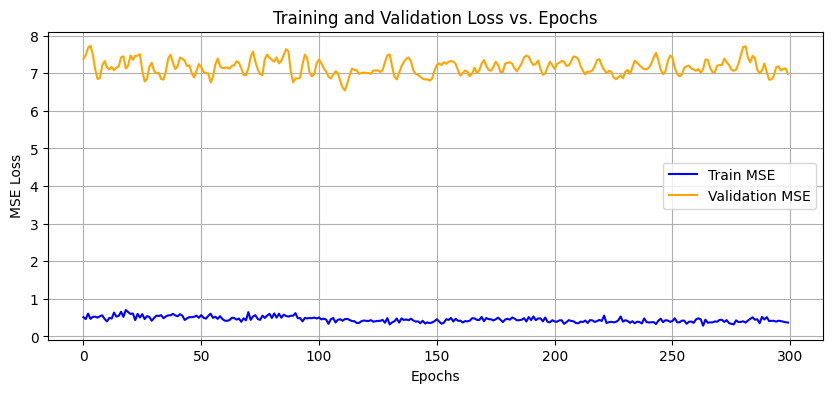

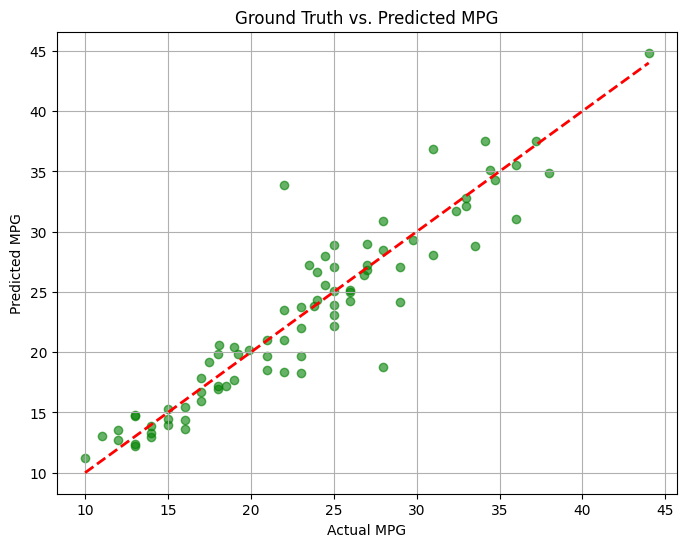

In [26]:
model.eval()
with torch.no_grad():
    y_test_pred = model(X_test_t)
    # The evaluation procedure: RMSE instead of Accuracy
    test_mse = criterion(y_test_pred, y_test_t).item()
    test_rmse = np.sqrt(test_mse)

print(f"\nFinal Neural Network Test RMSE: {test_rmse:.4f}")

# Figure 1: Training and Validation Loss Plot (UPDATED)
plt.figure(figsize=(10, 4))
plt.plot(train_losses, color='blue', label='Train MSE')
plt.plot(val_losses, color='orange', label='Validation MSE') # הוספת קו האימות
plt.title('Training and Validation Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

# Figure 2: Ground Truth vs. Predicted Scatter Plot
y_pred_np = y_test_pred.cpu().numpy()
y_true_np = y_test_t.cpu().numpy()

plt.figure(figsize=(8, 6))
plt.scatter(y_true_np, y_pred_np, alpha=0.6, color='green')
plt.plot([y_true_np.min(), y_true_np.max()], [y_true_np.min(), y_true_np.max()], 'r--', lw=2)
plt.title('Ground Truth vs. Predicted MPG')
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.grid(True)
plt.show()

### Conclusion: Neural Network vs. Classical Models

In this bonus task, we successfully adapted a Deep Neural Network for regression on the Auto MPG dataset. Our final model achieved a Test RMSE of **2.6436**. The training loss and the scatter plot demonstrate that the network effectively learned to predict fuel consumption.

However, when comparing this to our results from Part I, the Neural Network did not surpass our best classical model (KNN, RMSE ~2.27). This outcome is expected in machine learning: Deep Neural Networks require massive amounts of data to reach their full potential. On extremely small, tabular datasets like Auto MPG (fewer than 400 instances), simpler algorithms like KNN or polynomial regression are often more robust, less prone to overfitting, and ultimately perform slightly better than complex deep architectures.